In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from typing import Literal, Callable
import __future__

### Энтропия Шеннона

In [2]:
def shennon(y: np.ndarray[int]):
    """
    y : np.ndarray[int]
        Target vector of classes, each class decoded
        by integer number.
    """
    _, counts = np.unique(y, return_counts=True)
    probs = counts / y.shape[0]
    return -np.sum(probs * np.log(probs))

def gini(y: np.ndarray[int]):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / y.shape[0]
    return np.sum(probs * (1 - probs))

In [3]:
from __future__ import annotations


class DecisionTree:
    @dataclass
    class Leaf:
        value: float | int

    @dataclass
    class Node:
        left: DecisionTree.Node | DecisionTree.Leaf
        right: DecisionTree.Node | DecisionTree.Leaf
        feat_id: int
        th: float | int

    def __init__(
        self,
        criterion: Callable[[np.ndarray], float],
        accumulate_fn: Callable[[np.ndarray], float],
        max_depth: int = float("inf"),
        min_leaf: int = 1,
        feature_subspace_m: int = None,
    ):
        """
        Tree model for both regression and classification.

        Args:
            criterion (Callable): criterion to decide which decision is the best.
            accumulate_fn (Callable): function to accumulate values in leaf.
            max_depth (int): maximum depth of the tree.
            min_leaf (int): minimum number of samples in leaf.
            feature_subspace_m (int): number of features to use for each split. If None use all features.
        """
        self.criterion = criterion
        self.acc_fn = accumulate_fn
        self.max_depth = max_depth
        self.root = None
        self.min_leaf = min_leaf
        self.m = feature_subspace_m

    def _build_recursive(self, X: np.ndarray, y: np.ndarray, cur_depth=0):
        assert y.shape[0] >= self.min_leaf
        if cur_depth == self.max_depth or y.shape[0] == 1:
            return DecisionTree.Leaf(self.acc_fn(y))
        if self.m:
            features = np.random.choice(X.shape[1], self.m, replace=False)
            X_ = X[:, features]
        else:
            features = np.arange(X.shape[1])
            X_ = X

        min_crit = float("inf")
        best_feat, best_th = None, None
        for i in range(X_.shape[1]):
            for th in X_[:, i]:
                mask = X_[:, i] < th
                if mask.sum() < self.min_leaf or (~mask).sum() < self.min_leaf:
                    continue
                left_crit = self.criterion(y[mask])
                right_crit = self.criterion(y[~mask])
                cur_crit = (~mask).sum() * right_crit + mask.sum() * left_crit
                if cur_crit < min_crit:
                    min_crit = cur_crit
                    best_feat = features[i]
                    best_th = th
        if best_th is None:
            return DecisionTree.Leaf(self.acc_fn(y))
        return DecisionTree.Node(
            self._build_recursive(
                X[X[:, best_feat] < best_th],
                y[X[:, best_feat] < best_th],
                cur_depth + 1,
            ),
            self._build_recursive(
                X[X[:, best_feat] >= best_th],
                y[X[:, best_feat] >= best_th],
                cur_depth + 1,
            ),
            best_feat,
            best_th,
        )

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.root = self._build_recursive(X, y)
        return self

    def _predict_one(self, x):
        node = self.root
        while not isinstance(node, DecisionTree.Leaf):
            if x[node.feat_id] < node.th:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        return np.apply_along_axis(self._predict_one, 1, X)

In [4]:
class TreeRegressor(DecisionTree):
    def __init__(self, **kwargs):
        super().__init__(criterion=np.var, accumulate_fn=np.mean, **kwargs)
        
class TreeClassifier(DecisionTree):
    def __init__(self, criterion: Literal["gini", "shennon"]="gini", **kwargs):
        def fn(y):
            values, counts = np.unique(y, return_counts=True)
            return values[counts.argmax()]
        if criterion == "shennon":
            super().__init__(criterion=shennon, accumulate_fn=fn, **kwargs)
        elif criterion == "gini":
            super().__init__(criterion=gini, accumulate_fn=fn, **kwargs)
        else:
            raise ValueError("criterion must be `gini` or `shennon`.")

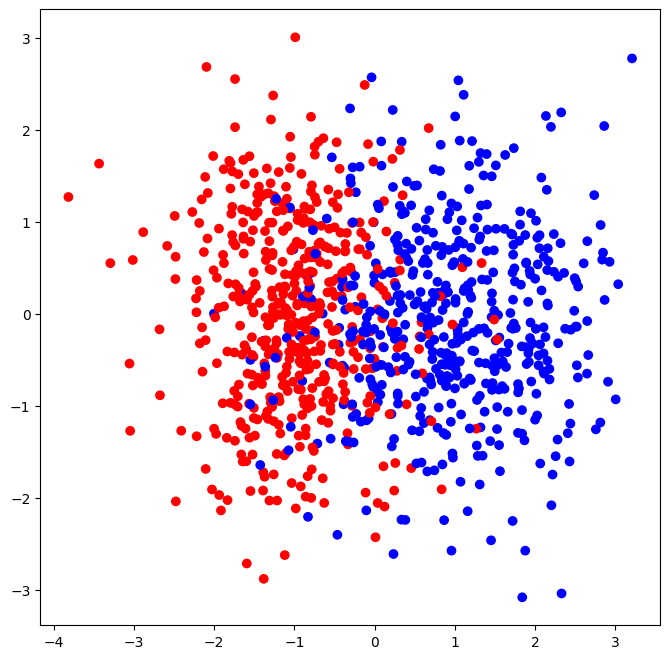

In [5]:
classification_data, classification_labels = datasets.make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=2,
    n_classes=2,
    n_redundant=0,
    n_clusters_per_class=2,
    random_state=3,
)

colors = ListedColormap(["red", "blue"])
light_colors = ListedColormap(["lightcoral", "lightblue"])

plt.figure(figsize=(8, 8))
plt.scatter(
    classification_data[:, 0],
    classification_data[:, 1],
    c=classification_labels,
    cmap=colors,
)
plt.show()

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(
    classification_data, classification_labels, test_size=0.3, random_state=1
)

[[133  13]
 [ 11 143]]
accuracy:  0.92


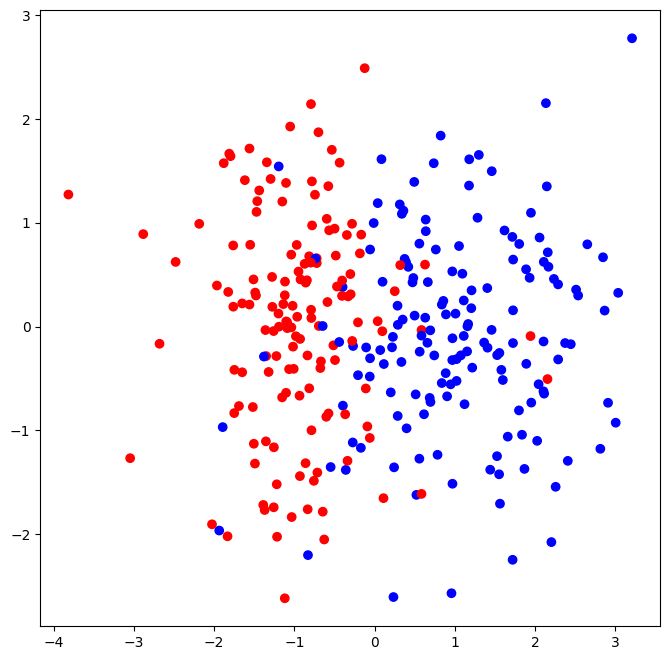

In [7]:
tree = TreeClassifier(max_depth=5).fit(train_data, train_labels)
y_pred = tree.predict(test_data)
print(confusion_matrix(test_labels, y_pred))
print("accuracy: ", accuracy_score(test_labels, y_pred))
colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8,8))
plt.scatter(test_data[:, 0], test_data[:, 1],
              c=y_pred, cmap=colors)

plt.show()

In [ ]:

tree = TreeClassifier(min_leaf=5).fit(train_data, train_labels)
def get_meshgrid(data, step=.05, border=1.2):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

plt.figure(figsize = (16, 7))

# график обучающей выборки
plt.subplot(1,2,1)
xx, yy = get_meshgrid(train_data)
mesh_predictions = np.array(tree.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

#print(np.c_[xx.ravel(), yy.ravel()])
train_accuracy = accuracy_score(train_labels, tree.predict(train_data))
test_accuracy = accuracy_score(test_labels, tree.predict(test_data))
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], c = train_labels, cmap = colors)
plt.title(f'Train accuracy={train_accuracy:.2f}')

# график тестовой выборки
plt.subplot(1,2,2)
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], c = test_labels, cmap = colors)
plt.title(f'Test accuracy={test_accuracy:.2f}')
plt.show()

## Random Forest

In [9]:
class RandomForest:
    def __init__(
        self,
        n_estimators=100,
        max_depth=None,
        task: Literal["regression", "classification"] = "regression",
    ):
        self.n_estimators = n_estimators
        self.kwargs = {"max_depth": max_depth}
        self.task = task
        if task == "regression":
            self.kwargs["min_leaf"] = 1
            self.ttype = TreeRegressor
        elif task == "classification":
            self.kwargs["min_leaf"] = 5
            self.ttype = TreeClassifier
        else:
            raise ValueError(f"Unknown task: {task}")

    def fit(self, X: np.ndarray, y: np.ndarray):
        d = X.shape[1]
        self.kwargs["feature_subspace_m"] = max(1, int(np.sqrt(d)) if self.task == "classification" else d // 3)
        self.forest = [self.ttype(**self.kwargs).fit(X, y) for _ in range(self.n_estimators)]
        return self

    def _predict_one(self, x: np.ndarray):
        y_pred = np.asarray([tree._predict_one(x) for tree in self.forest])
        if self.task == "regression":
            return np.mean(y_pred)
        return self.forest[0].acc_fn(y_pred)
    
    def predict(self, X):
        return np.apply_along_axis(self._predict_one, 1, X)

[[136  10]
 [  8 146]]
accuracy:  0.94


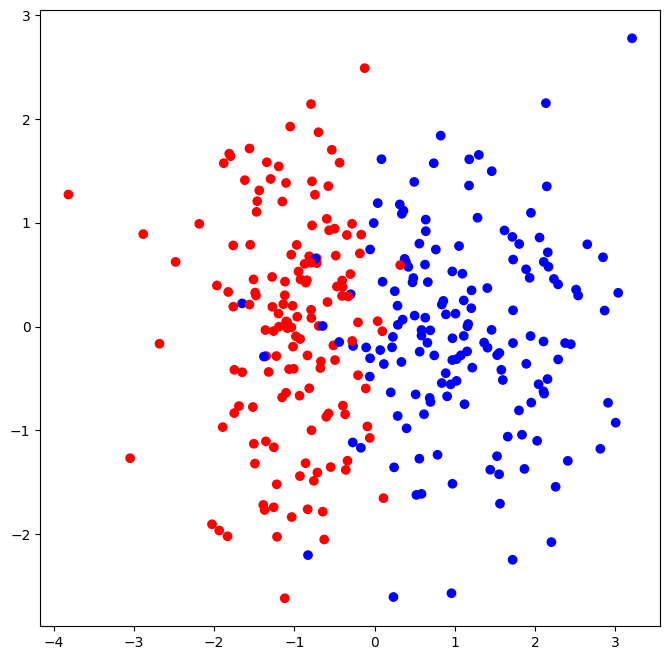

In [12]:
model = RandomForest(100, task="classification").fit(train_data, train_labels)
y_pred = model.predict(test_data)
print(confusion_matrix(test_labels, y_pred))
print("accuracy: ", accuracy_score(test_labels, y_pred))
colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8,8))
plt.scatter(test_data[:, 0], test_data[:, 1],
              c=y_pred, cmap=colors)

plt.show()

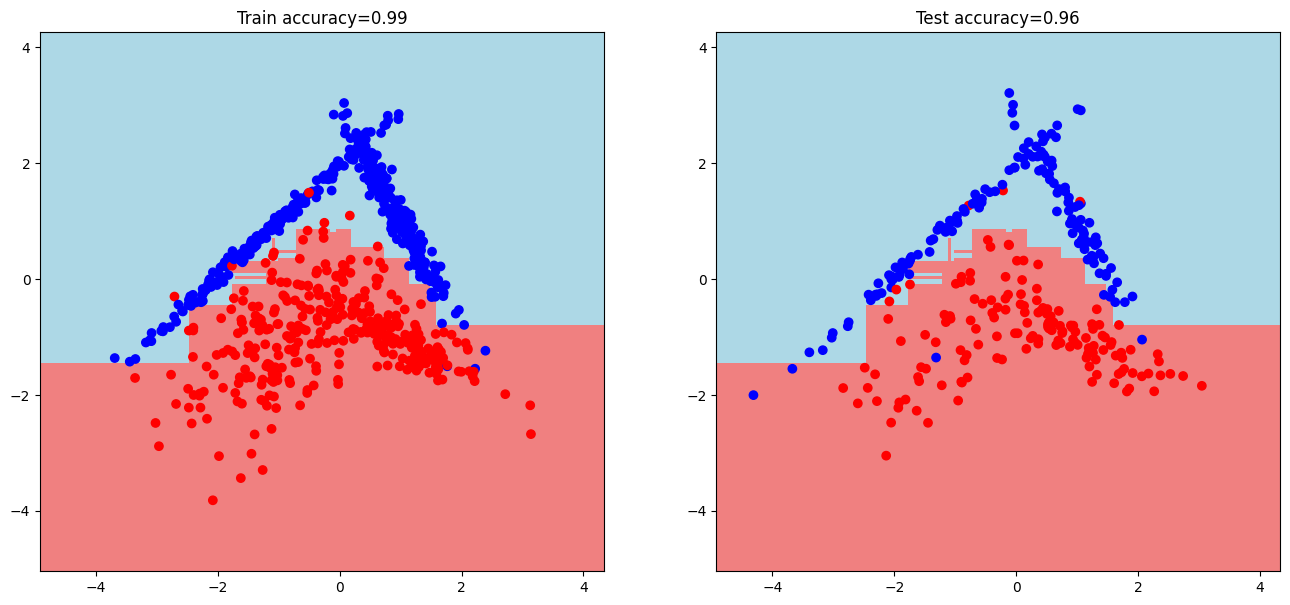

In [ ]:
model = RandomForest(100, task="classification").fit(train_data, train_labels)
def get_meshgrid(data, step=.05, border=1.2):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

plt.figure(figsize = (16, 7))

# график обучающей выборки
plt.subplot(1,2,1)
xx, yy = get_meshgrid(train_data)
mesh_predictions = np.array(model.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

#print(np.c_[xx.ravel(), yy.ravel()])
train_accuracy = accuracy_score(train_labels, model.predict(train_data))
test_accuracy = accuracy_score(test_labels, model.predict(test_data))
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], c = train_labels, cmap = colors)
plt.title(f'Train accuracy={train_accuracy:.2f}')

# график тестовой выборки
plt.subplot(1,2,2)
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], c = test_labels, cmap = colors)
plt.title(f'Test accuracy={test_accuracy:.2f}')
plt.show()